# [2025/11/14-10:25:52][falfilfa4py][init_env:0089][WARNING]: ECCODES_DEFINITION_PATH env var is defined: may result in unexpected issues if not consistent with linked eccodes library
 FADGRA: Field `S055SEASALT1' is not declared in `faFieldName.def' and has no encoded FMULTM and FMULTE


Difference stats:
  Mean: 1.565045219864783
  Max : 931.3176297647879
  RMS : 537.980515548176


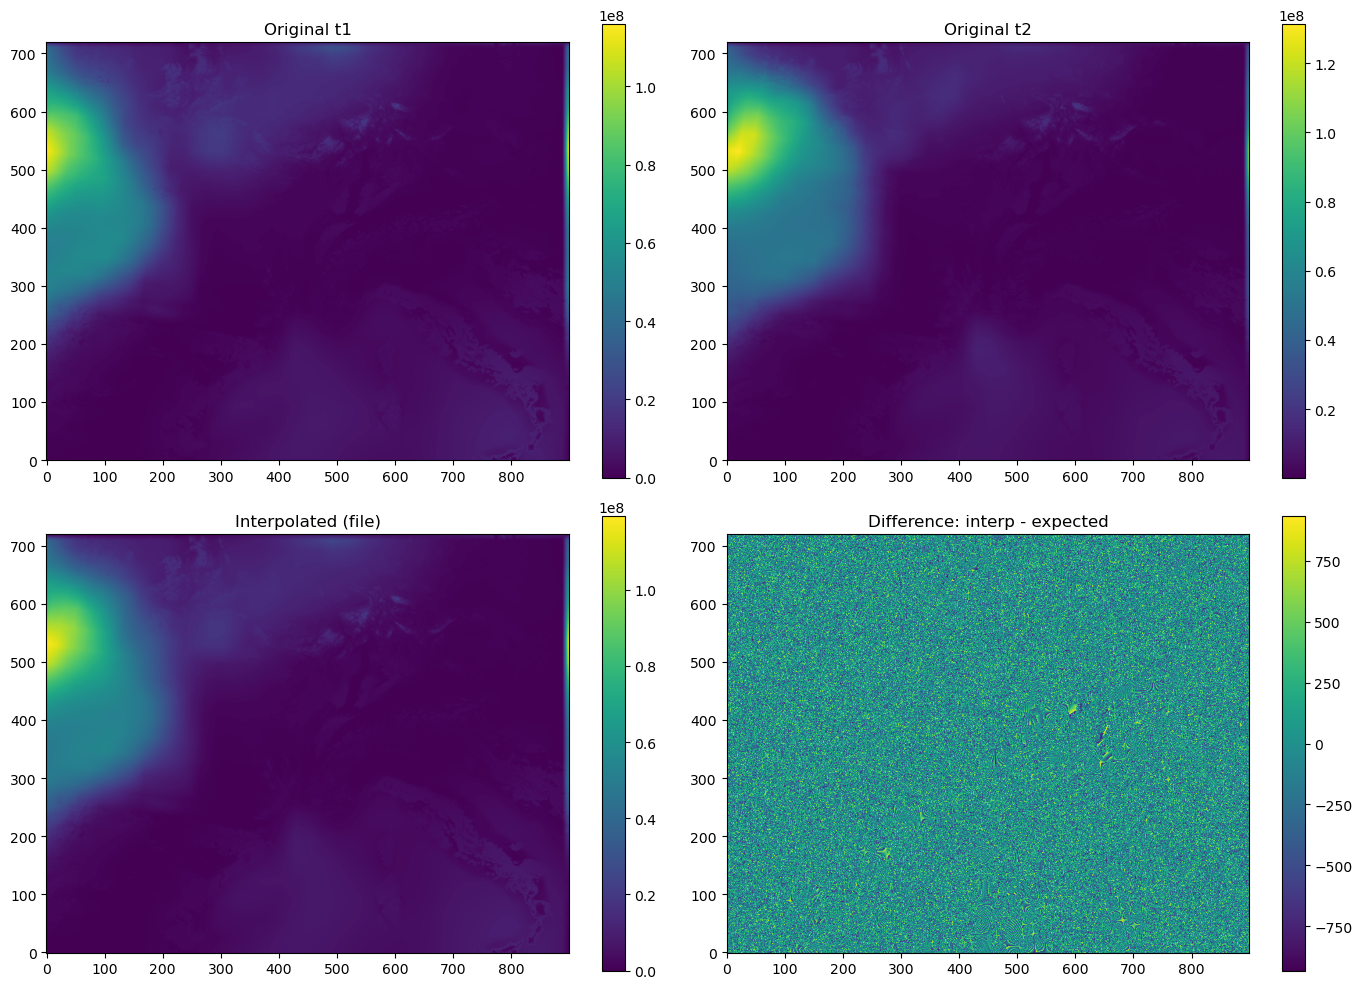

In [7]:

import numpy as np
import epygram
import matplotlib.pyplot as plt

epygram.init_env()

# ------------------------------------------------------------
# User settings
# ------------------------------------------------------------
path = '/home/lenobler/Data/tmp_CAMS_interp/'
file1 = "CAMS_AROME_20121017.0000"   # original t1
file2 = "CAMS_AROME_20121017.0300"   # original t2
filei = "CAMS_AROME_20121017.0100"   # interpolated t=01h

alpha = 1/3  # since 1h between 0h and 3h

field_key = "S055SEASALT1"  # choose a field key; or use r.listfields()[0]

# ------------------------------------------------------------
# Load resources
# ------------------------------------------------------------
r1 = epygram.formats.resource(path + file1, "r")
r2 = epygram.formats.resource(path + file2, "r")
ri = epygram.formats.resource(path + filei, "r")

# Select field
f1 = r1.readfield(field_key)
f2 = r2.readfield(field_key)
fi = ri.readfield(field_key)

# Read data arrays
d1 = f1.getdata()
d2 = f2.getdata()
di = fi.getdata()

# Linear interpolation expected
d_expected = (1 - alpha) * d1 + alpha * d2

# Difference field
d_diff = di - d_expected

print("Difference stats:")
print("  Mean:", np.mean(d_diff))
print("  Max :", np.max(np.abs(d_diff)))
print("  RMS :", np.sqrt(np.mean(d_diff**2)))

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.title("Original t1")
plt.imshow(d1, origin="lower")
plt.colorbar()

plt.subplot(2, 2, 2)
plt.title("Original t2")
plt.imshow(d2, origin="lower")
plt.colorbar()

plt.subplot(2, 2, 3)
plt.title("Interpolated (file)")
plt.imshow(di, origin="lower")
plt.colorbar()

plt.subplot(2, 2, 4)
plt.title("Difference: interp - expected")
plt.imshow(d_diff, origin="lower")
plt.colorbar()

plt.tight_layout()
plt.show()
